# Intra-case perspective

Control-flow drift exploration for `data/intra.xes`. Intra-case drifts reshape the
flow *within* cases: activities appear or vanish, directly-follows relations are
rewired, and the mix of trace variants shifts. Drift points are read from the log's
`rheon:metadata`; the full ground truth lives in `data/intra_meta.md`.

In [1]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


root = Path.cwd()
if not (root / "data").exists():
    root = root.parent
log_path = root / "data" / "intra.xes"


def read_drifts(xes_path, perspective):
    """Drift records from the log's rheon:metadata, normalised to start/end timestamps."""
    ns = "{http://www.xes-standard.org/}"
    meta = {}
    for ev, el in ET.iterparse(str(xes_path), events=("start", "end")):
        if ev == "end" and el.tag == f"{ns}string" and el.attrib.get("key") == "rheon:metadata":
            meta = json.loads(el.attrib["value"])
            break
        if ev == "start" and el.tag == f"{ns}trace":
            break
    rows = []
    for d in meta.get("drifts", []):
        if d["perspective"] != perspective:
            continue
        point = d.get("drift_point_date")
        rows.append({
            "id": d["id"], "type": d["type"], "mode": d["mode"],
            "start": pd.Timestamp(point or d["drift_start_date"]),
            "end": pd.Timestamp(point or d["drift_end_date"]),
            "changes": d.get("changes") or {},
        })
    return pd.DataFrame(rows)


def mark_drifts(ax, rows, color="black"):
    """Vertical line at each drift (shaded band for gradual ones), labelled by id."""
    ymax = ax.get_ylim()[1]
    for d in rows.itertuples():
        if d.mode == "gradual":
            ax.axvspan(d.start, d.end, color=color, alpha=0.08)
        ax.axvline(d.start, color=color, ls="--", lw=1.0, alpha=0.8)
        ax.text(d.start, ymax, d.id, ha="center", va="bottom", fontsize=8,
                bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.15"))


drifts = read_drifts(log_path, "intra-case")
drifts[["id", "type", "mode", "start", "end"]]

,id,type,mode,start,end
0,d01,control_flow,sudden,2020-02-03 19:09:16.841603+00:00,2020-02-03 19:09:16.841603+00:00
1,d02,control_flow,gradual,2020-02-29 03:31:14.472806+00:00,2020-03-12 19:42:13.288407+00:00


In [2]:
df = pm4py.read_xes(str(log_path)).rename(columns={
    "case:concept:name": "case_id",
    "concept:name": "activity",
    "time:timestamp": "timestamp",
})
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
# week bucket (tz dropped so weekly aggregates read in plain UTC wall time)
df["week"] = df["timestamp"].dt.tz_localize(None).dt.to_period("W").dt.start_time

cases = pd.DataFrame({
    "variant": df.groupby("case_id")["activity"].apply(",".join),
    "start": df.groupby("case_id")["timestamp"].min(),
    "length": df.groupby("case_id").size(),
}).reset_index()
cases["week"] = cases["start"].dt.tz_localize(None).dt.to_period("W").dt.start_time

activities = sorted(df["activity"].unique())
top_variants = cases["variant"].value_counts().head(8).index.tolist()
ACT = {a: to_hex(c) for a, c in zip(activities, sns.color_palette("husl", len(activities)))}
VAR = {v: to_hex(c) for v, c in zip(top_variants, sns.color_palette("tab20", len(top_variants)))}
df.head()

/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|███████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 13954.87it/s]


,event:id,activity,start_timestamp,timestamp,event:duration_min,org:resource,case_id,case:amount,case:region,week
0,evt_00000001,b,2020-01-01 00:00:00+00:00,2020-01-01 00:23:55.486069+00:00,23.924768,res_08,case_000001,938.2,region_3,2019-12-30
1,evt_00000002,g,2020-01-01 00:44:37.676267+00:00,2020-01-01 01:08:30.516156+00:00,23.880665,res_04,case_000001,938.2,region_3,2019-12-30
2,evt_00000003,h,2020-01-01 01:13:48.330860+00:00,2020-01-01 01:34:40.648397+00:00,20.871959,res_04,case_000001,938.2,region_3,2019-12-30
3,evt_00000004,b,2020-01-01 00:41:07.153626+00:00,2020-01-01 00:59:39.046357+00:00,18.531546,res_08,case_000002,1011.3,region_3,2019-12-30
4,evt_00000005,g,2020-01-01 01:23:03.068921+00:00,2020-01-01 01:51:32.222400+00:00,28.485891,res_03,case_000002,1011.3,region_3,2019-12-30


## Global structure

Aggregate shape of the whole log: how often each activity occurs, how cases split
across trace variants, how long traces are, and which activity follows which.

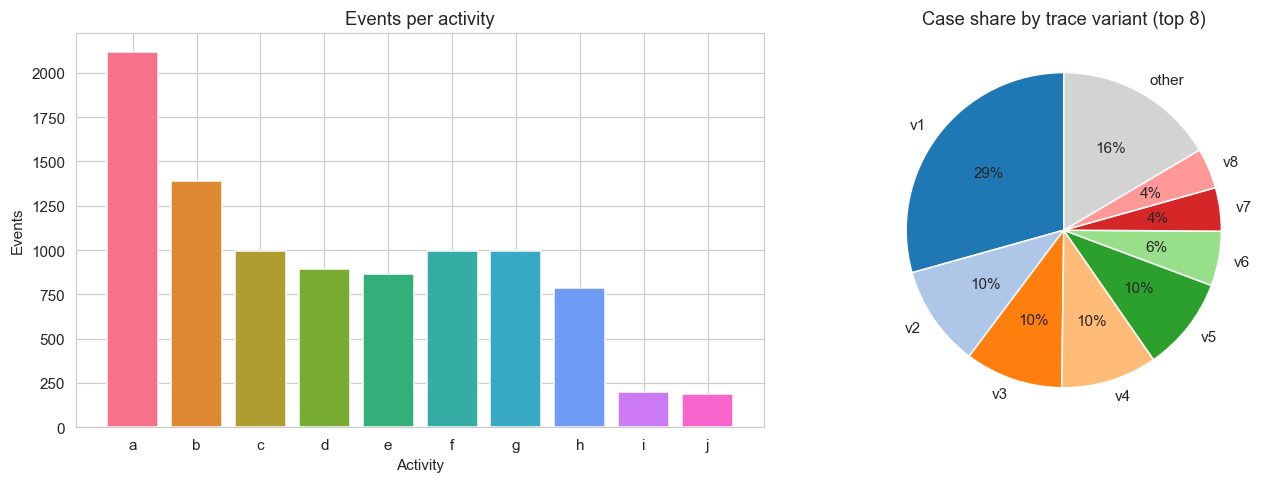

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df["activity"].value_counts().reindex(activities)
axes[0].bar(counts.index, counts.values, color=[ACT[a] for a in counts.index])
axes[0].set(title="Events per activity", xlabel="Activity", ylabel="Events")

vc = cases["variant"].value_counts()
sizes = list(vc.head(8).values) + [vc.iloc[8:].sum()]
labels = [f"v{i + 1}" for i in range(len(vc.head(8)))] + ["other"]
colors = [VAR[v] for v in vc.head(8).index] + ["lightgray"]
axes[1].pie(sizes, labels=labels, autopct="%1.0f%%", colors=colors, startangle=90)
axes[1].set_title("Case share by trace variant (top 8)")
plt.tight_layout()
plt.show()

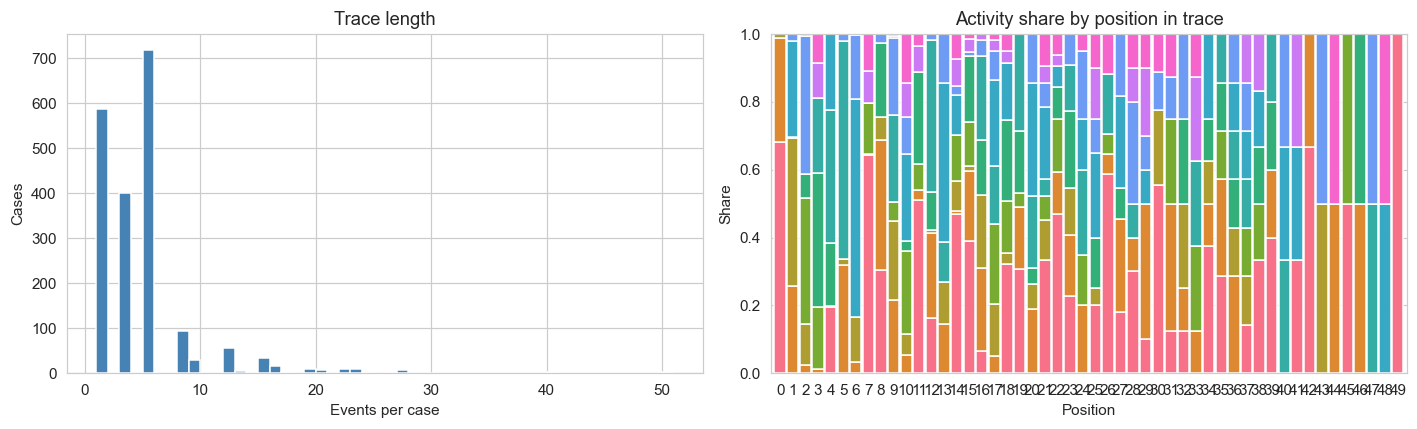

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cases["length"], bins=range(cases["length"].min(), cases["length"].max() + 2),
             color="steelblue", edgecolor="white")
axes[0].set(title="Trace length", xlabel="Events per case", ylabel="Cases")

pos = df.assign(pos=df.groupby("case_id").cumcount())
share = pd.crosstab(pos["pos"], pos["activity"]).reindex(columns=activities, fill_value=0)
share = share.div(share.sum(axis=1), axis=0)
share.plot(kind="bar", stacked=True, ax=axes[1], legend=False, width=0.9,
           color=[ACT[a] for a in share.columns])
axes[1].set(title="Activity share by position in trace", xlabel="Position", ylabel="Share")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

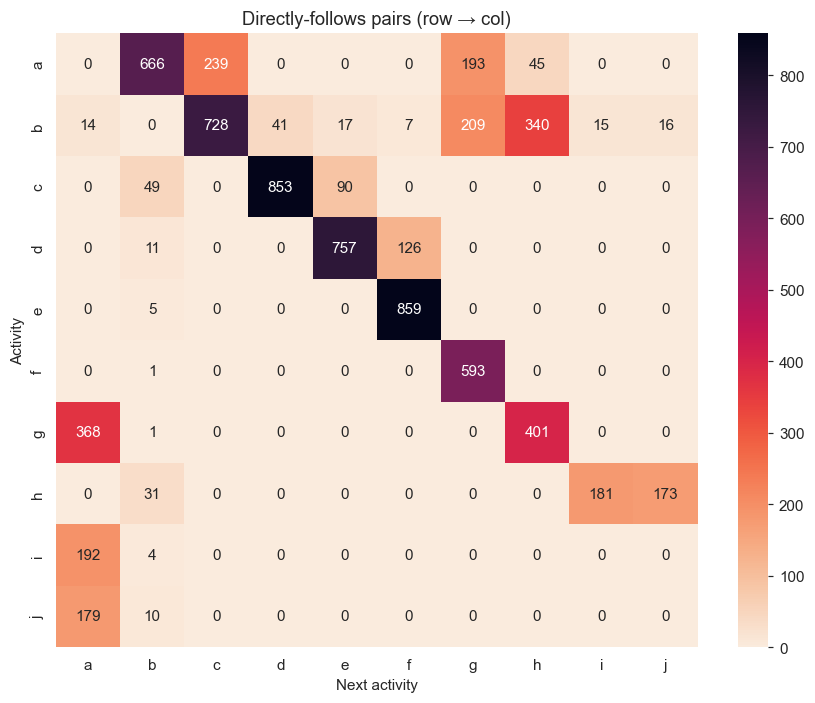

In [5]:
nxt = df.assign(next=df.groupby("case_id")["activity"].shift(-1)).dropna(subset=["next"])
dfg = pd.crosstab(nxt["activity"], nxt["next"]).reindex(index=activities, columns=activities, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(dfg, annot=True, fmt="d", cmap="rocket_r", ax=ax)
ax.set(title="Directly-follows pairs (row \u2192 col)", xlabel="Next activity", ylabel="Activity")
plt.tight_layout()
plt.show()

## Over time

Weekly views with drift markers. A control-flow drift surfaces as a change in the
variant mix, a burst of never-seen variants, and a shift in activity composition or
mean trace length.

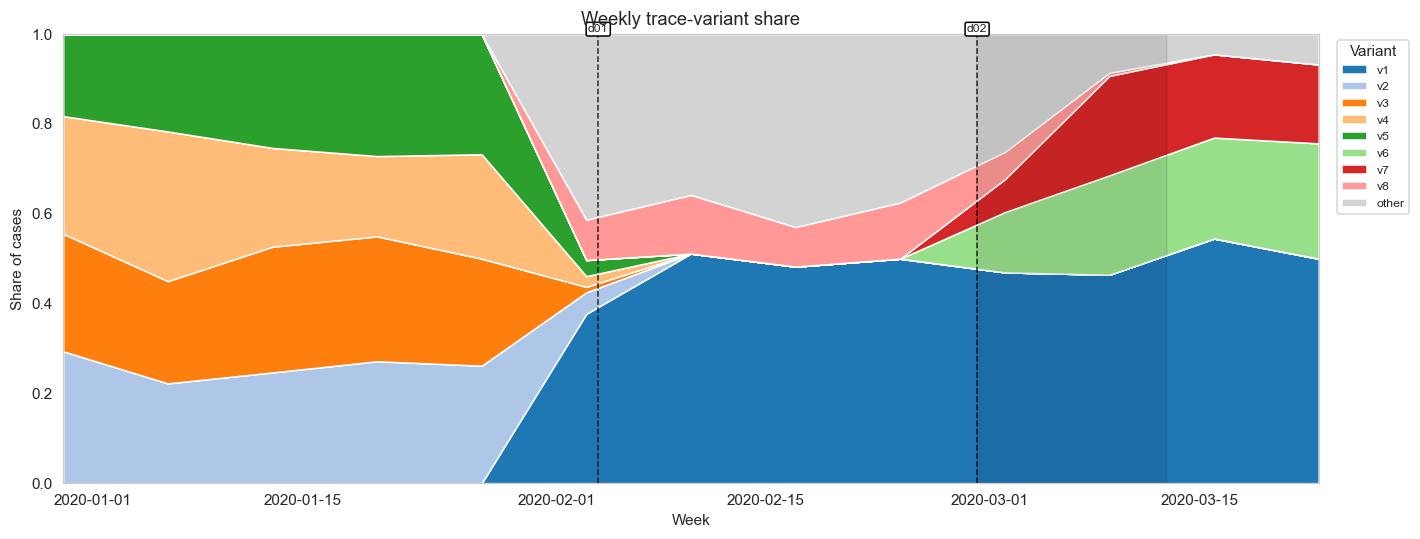

In [6]:
cases["bucket"] = cases["variant"].where(cases["variant"].isin(top_variants), "other")
order = top_variants + ["other"]
weekly = (cases.groupby(["week", "bucket"]).size().unstack(fill_value=0)
          .reindex(columns=order, fill_value=0).sort_index())
weekly = weekly.div(weekly.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(weekly.index, weekly.T.values,
             labels=[f"v{i + 1}" for i in range(len(top_variants))] + ["other"],
             colors=[VAR[v] for v in top_variants] + ["lightgray"])
ax.set(title="Weekly trace-variant share", xlabel="Week", ylabel="Share of cases", ylim=(0, 1))
ax.set_xlim(weekly.index.min(), weekly.index.max())
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Variant")
mark_drifts(ax, drifts)
plt.tight_layout()
plt.show()

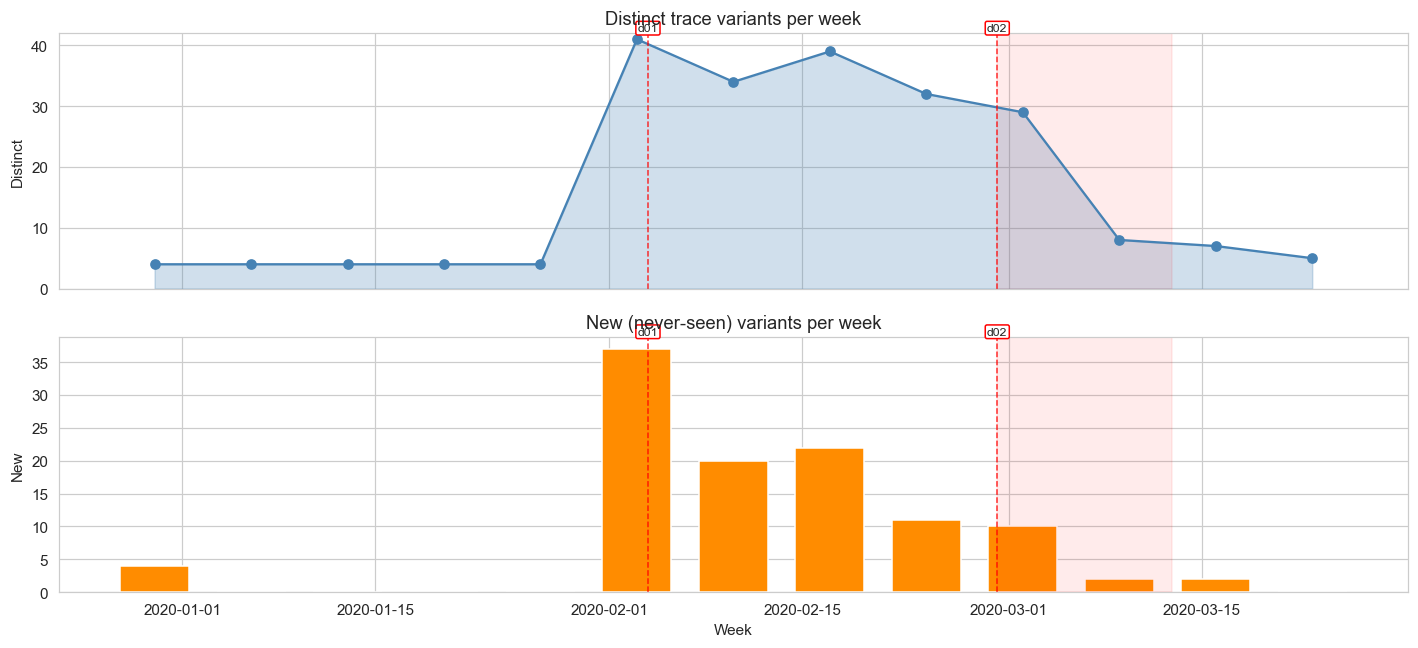

In [7]:
distinct = cases.groupby("week")["variant"].nunique()
seen, new_per_week = set(), []
for wk, g in cases.sort_values("start").groupby("week"):
    new_per_week.append((wk, len(set(g["variant"]) - seen)))
    seen |= set(g["variant"])
new_per_week = pd.DataFrame(new_per_week, columns=["week", "n"]).set_index("week")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].fill_between(distinct.index, distinct.values, alpha=0.25, color="steelblue")
axes[0].plot(distinct.index, distinct.values, marker="o", color="steelblue")
axes[0].set(title="Distinct trace variants per week", ylabel="Distinct", ylim=(0, distinct.max() + 1))
mark_drifts(axes[0], drifts, color="red")
axes[1].bar(new_per_week.index, new_per_week["n"], width=5, color="darkorange", edgecolor="white")
axes[1].set(title="New (never-seen) variants per week", xlabel="Week", ylabel="New")
mark_drifts(axes[1], drifts, color="red")
plt.tight_layout()
plt.show()

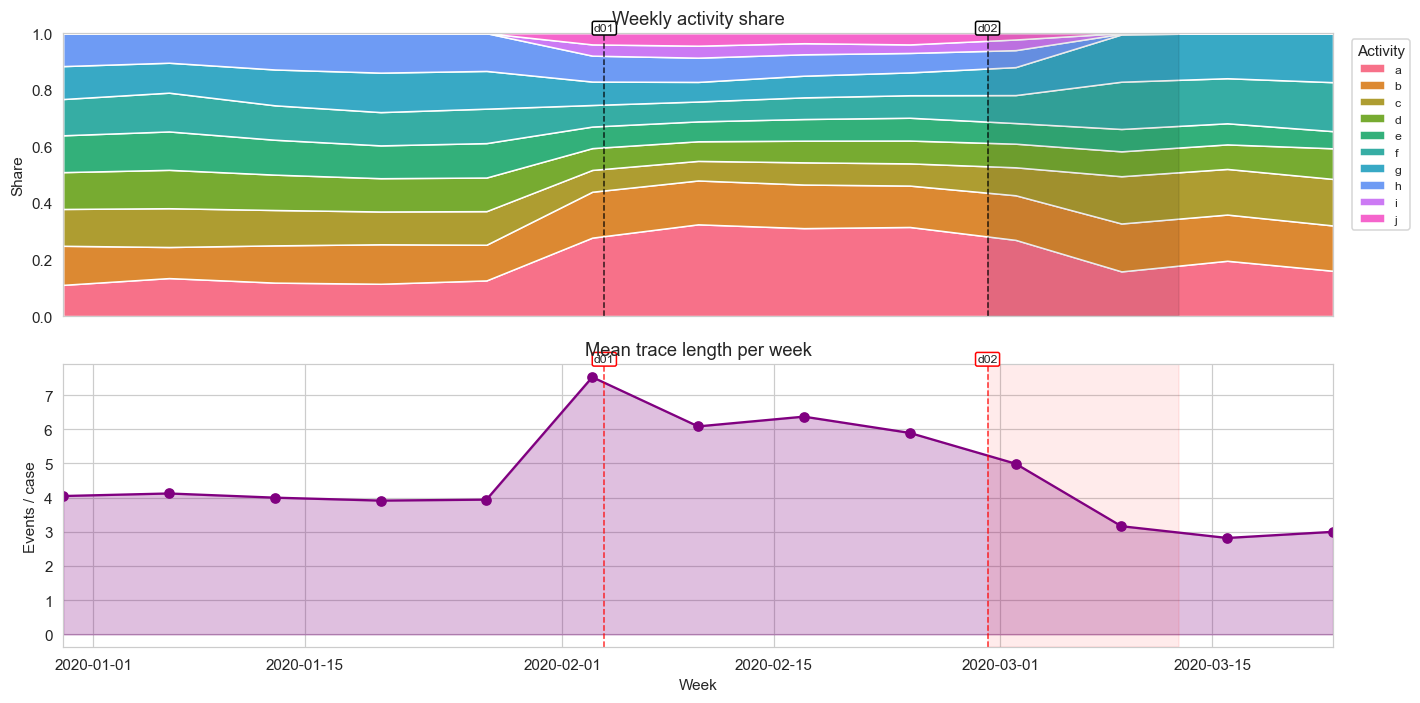

In [8]:
act_week = (df.groupby(["week", "activity"]).size().unstack(fill_value=0)
            .reindex(columns=activities, fill_value=0).sort_index())
act_week = act_week.div(act_week.sum(axis=1), axis=0)
mean_len = cases.groupby("week")["length"].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axes[0].stackplot(act_week.index, act_week.T.values, labels=act_week.columns,
                  colors=[ACT[a] for a in act_week.columns])
axes[0].set(title="Weekly activity share", ylabel="Share", ylim=(0, 1))
axes[0].set_xlim(act_week.index.min(), act_week.index.max())
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Activity")
mark_drifts(axes[0], drifts)
axes[1].fill_between(mean_len.index, mean_len.values, alpha=0.25, color="purple")
axes[1].plot(mean_len.index, mean_len.values, marker="o", color="purple")
axes[1].set(title="Mean trace length per week", xlabel="Week", ylabel="Events / case")
mark_drifts(axes[1], drifts, color="red")
plt.tight_layout()
plt.show()

## Before vs after a drift

Set `SELECTED` to a drift id and re-run. Cases are split by start time into a window
of `WINDOW_DAYS` on each side of the drift; left = before, right = after.

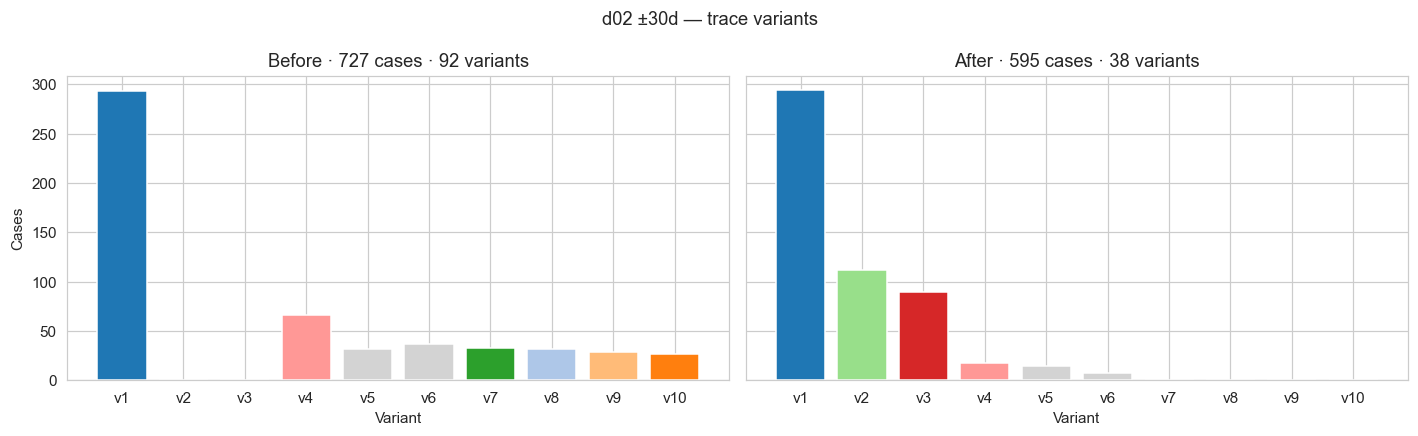

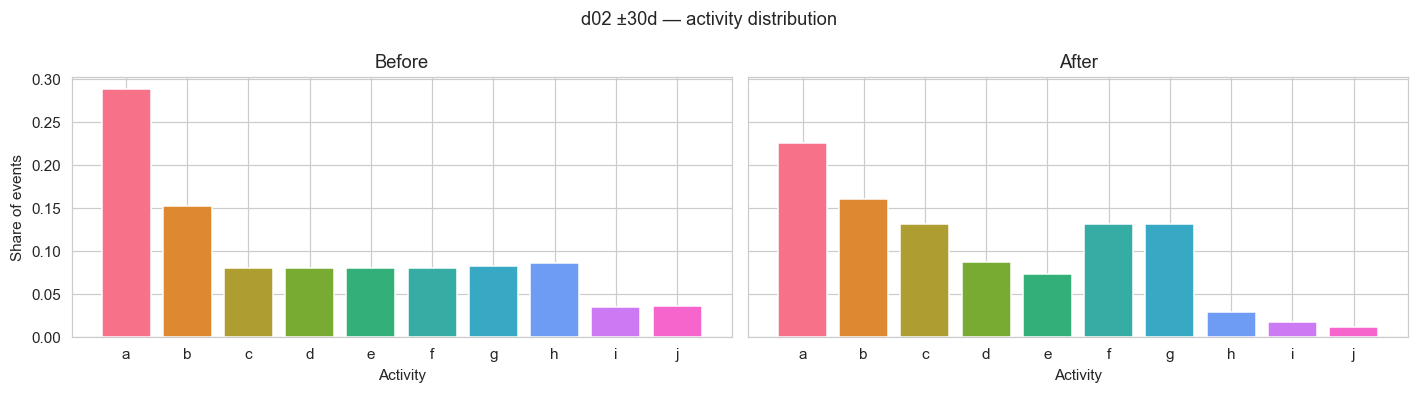

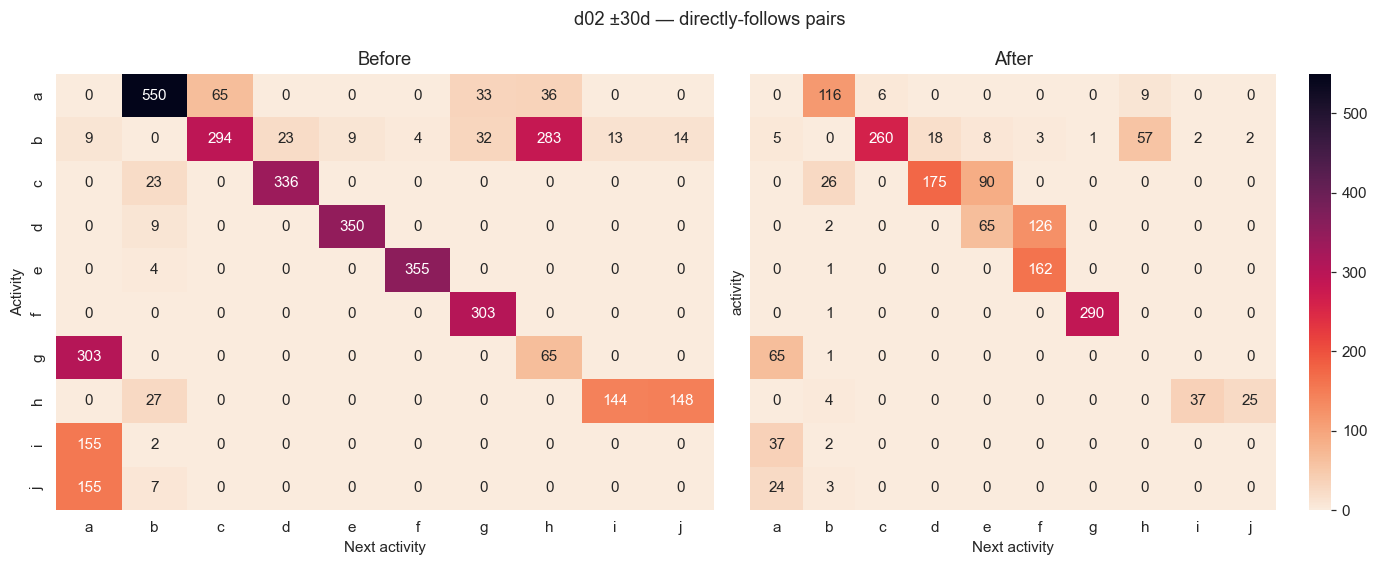

In [10]:
SELECTED = "d02"
WINDOW_DAYS = 30

point = drifts.set_index("id").loc[SELECTED, "start"]
lo, hi = point - pd.Timedelta(days=WINDOW_DAYS), point + pd.Timedelta(days=WINDOW_DAYS)
pre_c = cases[(cases["start"] >= lo) & (cases["start"] < point)]
post_c = cases[(cases["start"] >= point) & (cases["start"] < hi)]
pre = df[df["case_id"].isin(pre_c["case_id"])]
post = df[df["case_id"].isin(post_c["case_id"])]

# trace variants
win = pd.concat([pre_c, post_c])["variant"].value_counts().head(10).index.tolist()
short = {v: f"v{i + 1}" for i, v in enumerate(win)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sub, lbl in zip(axes, [pre_c, post_c], ["Before", "After"]):
    c = sub["variant"].value_counts().reindex(win, fill_value=0)
    ax.bar([short[v] for v in c.index], c.values,
           color=[VAR.get(v, "lightgray") for v in c.index])
    ax.set(title=f"{lbl} \u00b7 {len(sub)} cases \u00b7 {sub['variant'].nunique()} variants", xlabel="Variant")
axes[0].set_ylabel("Cases")
fig.suptitle(f"{SELECTED} \u00b1{WINDOW_DAYS}d \u2014 trace variants")
plt.tight_layout()
plt.show()

# activity distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, sub, lbl in zip(axes, [pre, post], ["Before", "After"]):
    s = sub["activity"].value_counts(normalize=True).reindex(activities, fill_value=0)
    ax.bar(s.index, s.values, color=[ACT[a] for a in s.index])
    ax.set(title=lbl, xlabel="Activity")
axes[0].set_ylabel("Share of events")
fig.suptitle(f"{SELECTED} \u00b1{WINDOW_DAYS}d \u2014 activity distribution")
plt.tight_layout()
plt.show()

# directly-follows
def dfg_of(sub):
    n = sub.assign(next=sub.groupby("case_id")["activity"].shift(-1)).dropna(subset=["next"])
    return pd.crosstab(n["activity"], n["next"]).reindex(index=activities, columns=activities, fill_value=0)

pre_dfg, post_dfg = dfg_of(pre), dfg_of(post)
vmax = max(pre_dfg.values.max(), post_dfg.values.max()) or 1
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
sns.heatmap(pre_dfg, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, cbar=False, ax=axes[0])
axes[0].set(title="Before", xlabel="Next activity", ylabel="Activity")
sns.heatmap(post_dfg, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, ax=axes[1])
axes[1].set(title="After", xlabel="Next activity")
fig.suptitle(f"{SELECTED} \u00b1{WINDOW_DAYS}d \u2014 directly-follows pairs")
plt.tight_layout()
plt.show()